**EDA dan Pre Processing**

In [47]:
# library python
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# library pribadi
import sys
import os
alamat_folder = r'D:\Dokumen coding\Data Science\Introduction\Definisi data science'
sys.path.append(alamat_folder)
import wordcloud_makerku


1. Basic EDA

In [6]:
data_komentar = pd.read_json('data/raw dataset komentar.json')
df_komentar = pd.DataFrame(data_komentar)

print(df_komentar.info(), "\n")
print(df_komentar.head())

<class 'pandas.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tanggal      2442 non-null   str    
 1   Jumlah Like  2291 non-null   float64
 2   Komentar     2442 non-null   str    
dtypes: float64(1), str(2)
memory usage: 57.4 KB
None 

      Tanggal  Jumlah Like                                           Komentar
0  2026-06-30          0.0  oalah bentar juga bubar srimulat x kud aja bub...
1  2026-06-30          0.0  Kopdes merah putih itu akan menghabisi pedagan...
2  2026-06-30          0.0  Tidak akan bertahan lama    bangkrut besar pas...
3  2026-06-30          0.0  Kami yakin jadi bangunan mangkrak...tiap kelur...
4  2026-06-29          0.0                                            ABS😂😂😂😂


In [10]:
df_komentar.isnull().sum()

Tanggal          0
Jumlah Like    151
Komentar         0
dtype: int64

In [11]:
df_komentar.duplicated().sum()

np.int64(54)

In [15]:
df_komentar[df_komentar.duplicated(keep=False)]

,Tanggal,Jumlah Like,Komentar
1411,2026-04-19,2.0,setau saya koperasi kebanyakan tidak berumur p...
1412,2026-04-19,2.0,setau saya koperasi kebanyakan tidak berumur p...
1646,2026-06-20,0.0,Bubarkan MBG
1654,2026-06-20,0.0,Bubarkan MBG
1684,2026-06-20,0.0,Pelaksana &amp; pengawas Podo malinge
...,...,...,...
2053,2026-06-18,0.0,SemOga MaSiih RejEki Di GaRudA hO ki
2054,2026-06-18,0.0,Konten Konten Yang diNanTi NaNtI gArUdA hOKi J...
2055,2026-06-18,0.0,ReviEw NyA JuJur bANgat GaRUda Ho Ki 💰 Bikin A...
2056,2026-06-18,0.0,Konten GarUdaHoki Kenapa Rame Bangat ya 💰


2. Pre processing

Menghapus duplikat komentar judol


In [36]:
kata_spam = ['garuda hoki', 'garudahoki', 'judi', 'slot', 'gacor', 'ga ruda hoki']

pola_spam = '|'.join(kata_spam)

df_komentar_bersih = df_komentar[~df_komentar['Komentar'].str.contains(pola_spam, case=False, na=False)]

print(df_komentar_bersih.tail())


         Tanggal  Jumlah Like  \
2437  2026-06-19          NaN   
2438  2026-06-19          NaN   
2439  2026-06-19          NaN   
2440  2026-06-19          NaN   
2441  2026-06-19          NaN   

                                               Komentar  
2437  Per unit Kdmp Nilai kontrak fisik 1.6 milyar<b...  
2438  Lht saja 5 thn lg KDMP masih ada atau sdh jd F...  
2439             Wah asik nih<br>Tumben ada ad 2 narsum  
2440   Jangan sampai KDKMP menjadi bancakan seperti BGN  
2441  sbnrnya kdmp ni penyelamat ekonomi desa atau p...  


3. EDA kembali

In [37]:
print(df_komentar_bersih.info())

<class 'pandas.DataFrame'>
Index: 2426 entries, 0 to 2441
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tanggal      2426 non-null   str    
 1   Jumlah Like  2275 non-null   float64
 2   Komentar     2426 non-null   str    
dtypes: float64(1), str(2)
memory usage: 75.8 KB
None


In [32]:
df_komentar_bersih.duplicated().sum()



np.int64(46)

In [34]:
df_komentar_bersih[df_komentar_bersih.duplicated()]

,Tanggal,Jumlah Like,Komentar
1412,2026-04-19,2.0,setau saya koperasi kebanyakan tidak berumur p...
1654,2026-06-20,0.0,Bubarkan MBG
1685,2026-06-20,0.0,Pelaksana &amp; pengawas Podo malinge
1711,2026-06-19,0.0,Kebijakan pemerintah sekarang didesain buat ja...
1865,2026-06-19,0.0,NEGARA INI MAU D BAWAK HANCUR SEPERTI ZIMBABWE...
1866,2026-06-19,0.0,NEGARA INI MAU D BAWAK HANCUR SEPERTI ZIMBABWE...
1980,2026-06-18,0.0,Ceritanya bikin merinding! ｇａ ｒｕｄａ ｈｏｋｉ bikin ...
1981,2026-06-18,0.0,Tutorialnya jelas banget! ｇａ ｒｕｄａ ｈｏｋｉ bikin a...
2006,2026-06-18,0.0,Ceritanya bikin merinding! ｇａ ｒｕｄａ ｈｏｋｉ bikin ...
2008,2026-06-18,0.0,"Modal 20k doang, hasilnya 35jt! 𝑮𝑨 𝑹𝑼 𝑫𝑨𝑯𝑶 𝑲𝑰⚡..."


4. Prerocessing kembali

Menghaous duplicate sepenuhnya

In [ ]:
df_komentar_bersih.drop_duplicates(keep='first', inplace=True, ignore_index=True)


In [39]:

print(df_komentar_bersih.info())

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tanggal      2380 non-null   str    
 1   Jumlah Like  2229 non-null   float64
 2   Komentar     2380 non-null   str    
dtypes: float64(1), str(2)
memory usage: 55.9 KB
None


In [40]:
df_komentar_bersih.duplicated().sum()

np.int64(0)

In [44]:
jumlah_kata = df_komentar_bersih['Komentar'].apply(lambda x: len(str(x).split()))

print(jumlah_kata)

0       11
1       38
2       10
3       16
4        1
        ..
2375    17
2376    12
2377     7
2378     7
2379    12
Name: Komentar, Length: 2380, dtype: int64


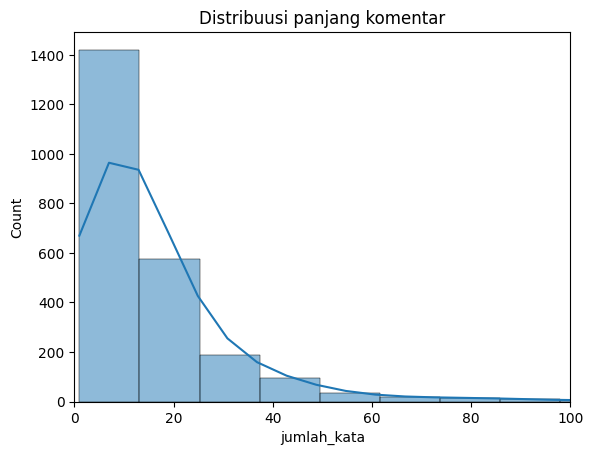

In [48]:
sns.histplot(df_komentar_bersih, x=jumlah_kata, kde=True)
plt.xlabel('jumlah_kata')
plt.xlim(0, 100)

plt.title('Distribuusi panjang komentar')
plt.show()

In [ ]:
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace(r'<.*?>',' ', regex=True)
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace('br>',' ', regex=False)
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace('b>',' ', regex=False)
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace('<b>',' ', regex=False)
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace('<b',' ', regex=False)

In [100]:
# 1. Gabungkan regex URL dan regex karakter unik bot spam
regex_spam_url = r'https?://\S+|www\.\S+|\b[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b\S*|[\U0001d400-\U0001d7ff\U0001f1e6-\U0001f1ff]{3,}'

# 2. Filter DataFrame (Tanda ~ artinya simpan yang TIDAK cocok dengan regex spam)
df_komentar_bersih = df_komentar_bersih[~df_komentar_bersih['Komentar'].str.contains(regex_spam_url, regex=True, na=False)]

# 3. Reset index agar nomor barisnya kembali rapi dari 0
df_komentar_bersih.reset_index(drop=True, inplace=True)

In [101]:
# 1. Definisikan pola regex super ketat untuk variasi "garudahoki"
pola_spam_bandel = r'g+\s*a+\s*r+\s*u+\s*d+\s*a+\s*h+\s*o+\s*k+\s*i+'

# 2. Filter dataframe (buang baris yang terdeteksi pola tersebut)
# case=False memastikan ia menangkap baik huruf besar maupun kecil (GaRUda, g a r u d a, dll)
df_komentar_bersih = df_komentar_bersih[~df_komentar_bersih['Komentar'].str.contains(pola_spam_bandel, case=False, regex=True, na=False)]

# 3. Opsional: Reset index agar rapi kembali
df_komentar_bersih.reset_index(drop=True, inplace=True)

# Cek hasilnya
print("Sisa baris data:", len(df_komentar_bersih))

Sisa baris data: 2258


In [120]:
df_komentar_bersih = df_komentar_bersih.drop(index=range(1879, 1896))
df_komentar_bersih.reset_index(drop=True, inplace=True)

In [121]:
print(df_komentar_bersih.tail())

         Tanggal  Jumlah Like  \
2222  2026-06-19          NaN   
2223  2026-06-19          NaN   
2224  2026-06-19          NaN   
2225  2026-06-19          NaN   
2226  2026-06-19          NaN   

                                               Komentar  
2222  Per unit Kdmp Nilai kontrak fisik 1.6 milyar D...  
2223  Lht saja 5 thn lg KDMP masih ada atau sdh jd F...  
2224                Wah asik nih Tumben ada ad 2 narsum  
2225   Jangan sampai KDKMP menjadi bancakan seperti BGN  
2226  sbnrnya kdmp ni penyelamat ekonomi desa atau p...  


In [122]:
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.replace(r'\s+',' ', regex=True)
df_komentar_bersih['Komentar'] = df_komentar_bersih['Komentar'].str.strip()

In [72]:
print(df_komentar_bersih.head())

      Tanggal  Jumlah Like                                           Komentar
0  2026-06-30          0.0  oalah bentar juga bubar srimulat x kud aja bub...
1  2026-06-30          0.0  Kopdes merah putih itu akan menghabisi pedagan...
2  2026-06-30          0.0  Tidak akan bertahan lama bangkrut besar pasak ...
3  2026-06-30          0.0  Kami yakin jadi bangunan mangkrak tiap kelurah...
4  2026-06-29          0.0                                            ABS😂😂😂😂


In [112]:
print(df_komentar_bersih.tail())

         Tanggal  Jumlah Like  \
2239  2026-06-19          NaN   
2240  2026-06-19          NaN   
2241  2026-06-19          NaN   
2242  2026-06-19          NaN   
2243  2026-06-19          NaN   

                                               Komentar  
2239  Per unit Kdmp Nilai kontrak fisik 1.6 milyar D...  
2240  Lht saja 5 thn lg KDMP masih ada atau sdh jd F...  
2241                Wah asik nih Tumben ada ad 2 narsum  
2242   Jangan sampai KDKMP menjadi bancakan seperti BGN  
2243  sbnrnya kdmp ni penyelamat ekonomi desa atau p...  


In [68]:
# Mengambil teks asli di baris index ke-4 dan menampilkannya secara mentah
print(repr(df_komentar_bersih['Komentar'].iloc[4]))

'ABS😂😂😂😂'


In [123]:
data_disimpan = df_komentar_bersih[['Tanggal', 'Komentar']]


In [124]:
data_disimpan[data_disimpan.duplicated()]
data_disimpan.drop_duplicates(keep='first', inplace=True, ignore_index=True)

In [126]:
data_disimpan.to_csv('data/dataset komentar bersih.csv', index=False, encoding='utf-8')

print("data berhasil disimpan")

data berhasil disimpan
